# CNN Based Forest Fire Detection

## Pattern Recognition Project - Phase II

### Student
Satya Sai Karthik Guttula

### Objective
The objective of this project is to classify forest images into two categories:

- Fire
- No Fire

using Convolutional Neural Networks (CNN) and Transfer Learning.

### Dataset
The Wildfire Dataset from Kaggle

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Libraries Imported Successfully")

2026-06-07 09:27:26.739645: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780824446.932826      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780824446.990632      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780824447.439573      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780824447.439638      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780824447.439642      58 computation_placer.cc:177] computation placer alr

Libraries Imported Successfully


## Dataset Loading

In [2]:
train_dir = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/train"

val_dir = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val"

test_dir = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test"

print("Dataset Paths Loaded")

Dataset Paths Loaded


## Data Preprocessing and Augmentation

In [3]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 1887 images belonging to 2 classes.
Found 402 images belonging to 2 classes.
Found 410 images belonging to 2 classes.


## Dataset Visualization

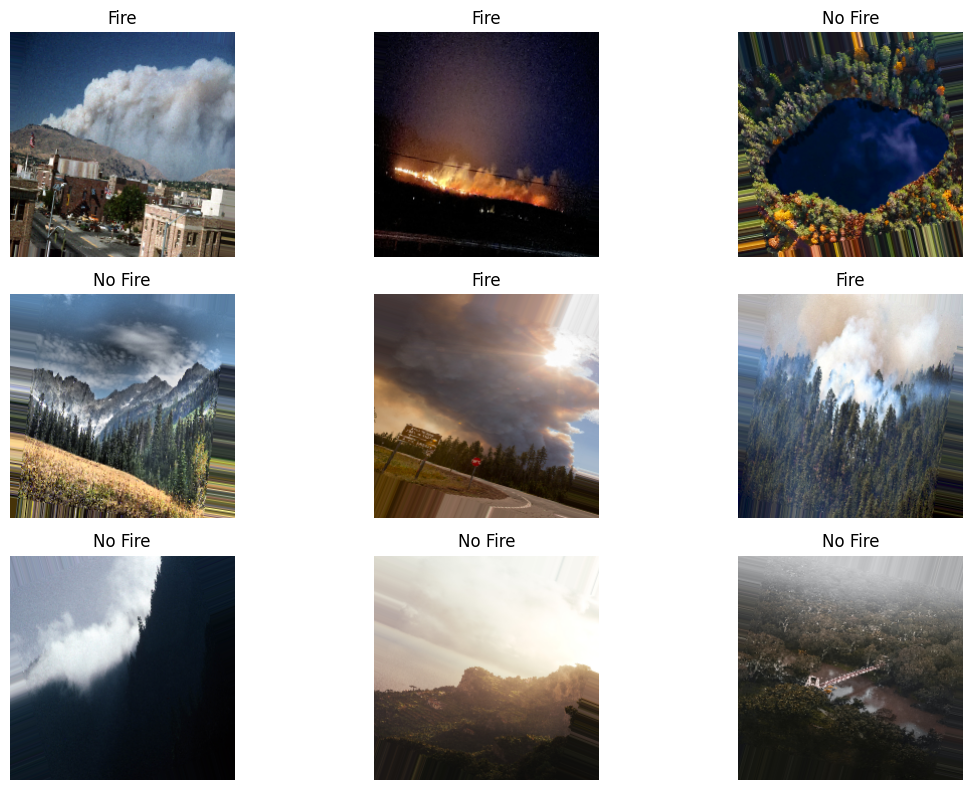

In [4]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])

    if labels[i] == 1:
        plt.title("No Fire")
    else:
        plt.title("Fire")

    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN Model Development

In [5]:
cnn_model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780824474.377970      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## CNN Model Training

In [6]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


I0000 00:00:1780824503.001170     152 service.cc:152] XLA service 0x79c658006810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780824503.001212     152 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780824503.476858     152 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/59 ━━━━━━━━━━━━━━━━━━━━ 15:45 16s/step - accuracy: 0.5938 - loss: 0.6876

I0000 00:00:1780824508.129627     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 7/59 ━━━━━━━━━━━━━━━━━━━━ 7:33 9s/step - accuracy: 0.5285 - loss: 2.1032

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


34/59 ━━━━━━━━━━━━━━━━━━━━ 3:38 9s/step - accuracy: 0.5641 - loss: 1.2629

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


59/59 ━━━━━━━━━━━━━━━━━━━━ 646s 11s/step - accuracy: 0.6264 - loss: 0.7222 - val_accuracy: 0.6741 - val_loss: 0.5845
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 473s 8s/step - accuracy: 0.7038 - loss: 0.5597 - val_accuracy: 0.6667 - val_loss: 0.6105
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 464s 8s/step - accuracy: 0.6969 - loss: 0.5548 - val_accuracy: 0.7438 - val_loss: 0.4759
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 438s 7s/step - accuracy: 0.7483 - loss: 0.5087 - val_accuracy: 0.6965 - val_loss: 0.5865
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 446s 8s/step - accuracy: 0.7615 - loss: 0.4908 - val_accuracy: 0.7488 - val_loss: 0.4909
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 438s 7s/step - accuracy: 0.7705 - loss: 0.4733 - val_accuracy: 0.7836 - val_loss: 0.4510
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 459s 8s/step - accuracy: 0.7795 - loss: 0.4640 - val_accuracy: 0.7687 - val_loss: 0.4890
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 460s 8s/step - accuracy: 0.7870 - loss: 0.4694 - val_accuracy: 0.7239 - val_loss: 0

## CNN Model Evaluation

In [7]:
test_loss, test_accuracy = cnn_model.evaluate(test_generator)

print("CNN Accuracy:", test_accuracy)
print("CNN Loss:", test_loss)

 5/13 ━━━━━━━━━━━━━━━━━━━━ 51s 6s/step - accuracy: 0.7329 - loss: 0.5677

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 6/13 ━━━━━━━━━━━━━━━━━━━━ 55s 8s/step - accuracy: 0.7323 - loss: 0.5679

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 118s 9s/step - accuracy: 0.8073 - loss: 0.4175
CNN Accuracy: 0.8073170781135559
CNN Loss: 0.417488157749176


## Accuracy and Loss Curves

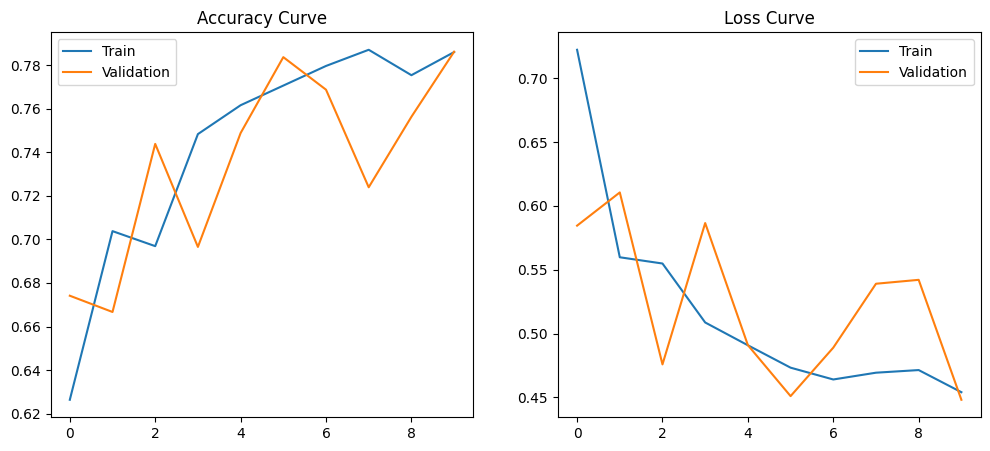

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy Curve')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Curve')
plt.legend(['Train','Validation'])

plt.savefig('/kaggle/working/accuracy_loss_curve.pdf')
plt.show()

## Confusion Matrix

 5/13 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 6/13 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 96s 8s/step


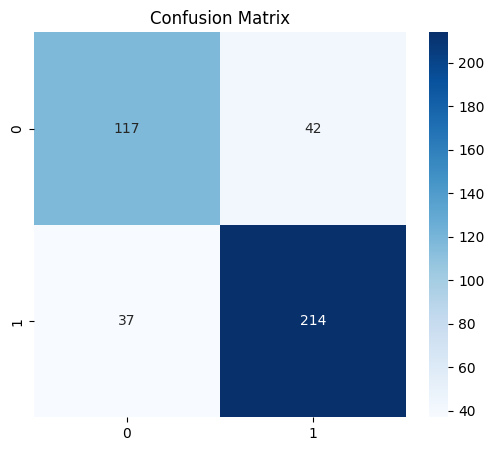

In [9]:
predictions = cnn_model.predict(test_generator)

y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(
    test_generator.classes,
    y_pred
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.savefig('/kaggle/working/confusion_matrix.pdf')

plt.show()

## Classification Report

In [10]:
report = classification_report(
    test_generator.classes,
    y_pred,
    target_names=['Fire','No Fire']
)

print(report)

              precision    recall  f1-score   support

        Fire       0.76      0.74      0.75       159
     No Fire       0.84      0.85      0.84       251

    accuracy                           0.81       410
   macro avg       0.80      0.79      0.80       410
weighted avg       0.81      0.81      0.81       410



## Transfer Learning using MobileNetV2

In [11]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
12/59 ━━━━━━━━━━━━━━━━━━━━ 4:36 6s/step - accuracy: 0.5909 - loss: 0.7291

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


50/59 ━━━━━━━━━━━━━━━━━━━━ 55s 6s/step - accuracy: 0.7164 - loss: 0.5467 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


59/59 ━━━━━━━━━━━━━━━━━━━━ 474s 8s/step - accuracy: 0.7976 - loss: 0.4385 - val_accuracy: 0.8507 - val_loss: 0.3547
Epoch 2/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 478s 8s/step - accuracy: 0.8516 - loss: 0.3283 - val_accuracy: 0.8234 - val_loss: 0.4169
Epoch 3/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 440s 7s/step - accuracy: 0.8596 - loss: 0.3101 - val_accuracy: 0.8557 - val_loss: 0.3219
Epoch 4/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 435s 7s/step - accuracy: 0.8755 - loss: 0.2752 - val_accuracy: 0.8134 - val_loss: 0.4866
Epoch 5/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 450s 8s/step - accuracy: 0.8940 - loss: 0.2422 - val_accuracy: 0.8607 - val_loss: 0.3175


In [13]:
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(
    test_generator
)

print("MobileNetV2 Accuracy:", mobilenet_accuracy)

 5/13 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.8305 - loss: 0.4491

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 6/13 ━━━━━━━━━━━━━━━━━━━━ 37s 5s/step - accuracy: 0.8301 - loss: 0.4484

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 95s 8s/step - accuracy: 0.8902 - loss: 0.2686
MobileNetV2 Accuracy: 0.8902438879013062


## Model Comparison

In [14]:
comparison = pd.DataFrame({
    "Model":["Custom CNN","MobileNetV2"],
    "Accuracy":[test_accuracy,mobilenet_accuracy]
})

comparison

,Model,Accuracy
0,Custom CNN,0.807317
1,MobileNetV2,0.890244


## Save Trained Model

In [15]:
cnn_model.save('/kaggle/working/forest_fire_cnn.h5')

print("Model Saved Successfully")

Model Saved Successfully


In [16]:
import os

for root, dirs, files in os.walk('/kaggle/working'):
    for file in files:
        print(os.path.join(root,file))

/kaggle/working/confusion_matrix.pdf
/kaggle/working/accuracy_loss_curve.pdf
/kaggle/working/forest_fire_cnn.h5
/kaggle/working/.virtual_documents/__notebook_source__.ipynb
